# Demo

This is a small demo, running the main functions with 50 instead of ~50000 bootstraping samples.

Consult the readme.md for instructions how to install the required packages.

Download the required death [data](https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/DEMO_R_MWK2_05/?format=SDMX-CSV&lang=en&label=both) and save it to ./data/Deaths.csv

Execution of the demo should run within minutes on a normal desktop PC; however, systems with less than 16 GB of RAM may experience swapping.

**Disclamer: Running the bootstrap with 50 instead of 50000 samples generates unprecise results and is only meant for demo/testing purposes.**

### Country Infection Fatality Rate (CIFR)

In [1]:
import pandas as pd

import sys
sys.path.append("../code")
from country_ifr import country_ifr
from load_dataset import load_population

# Load the data
mortality_curve_params = pd.read_csv('../data/MortalityCurveParams.csv', index_col=0)
mortality_curve_params = mortality_curve_params.iloc[:,:50] # reduce sample size to 50
population_yearly, _ = load_population()
population_yearly = population_yearly.T


eu_countries = ["Sweden","Denmark","Finland","Norway","Austria","Belgium","France","Germany","United Kingdom","Switzerland","Netherlands","Greece","Italy","Portugal","Spain","Cyprus","Malta","Iceland","Albania","Bulgaria","Czechia","Croatia","Estonia","Poland","Romania","Serbia","Slovakia","Slovenia","Montenegro","Latvia","Lithuania","Hungary"]
population_yearly.loc[:, "Europe**"] = population_yearly.loc[:, eu_countries].sum(axis=1)

# Calculate country IFR
CIFR = pd.DataFrame(columns=population_yearly.columns)

for params in mortality_curve_params.T.iterrows():
    CIFR.loc[params[0], :] = country_ifr(params[1].to_list(), population_yearly)


### Surplus deaths

In [2]:
import pandas as pd
import numpy as np

from load_dataset import load_covid_deaths, load_deaths, load_population
from excess_deaths import calculate_max_deaths

window = 3

# Load the data
_, population = load_population()
population.loc["Europe**", :] = population.loc[eu_countries, :].sum(axis=0)

deaths = load_deaths()
for year in ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']:
    deaths.loc[(year, 'Europe**'), :] = deaths.loc[(year, eu_countries), :].sum()
    
covid_deaths = load_covid_deaths()
covid_deaths.loc["Europe**"] = covid_deaths.loc[eu_countries].sum()

# Remove countries with no available data
common_countries = list(set(deaths.index.droplevel(0)) & set(population.index))

CIFR = CIFR.loc[:, common_countries]
population = population.loc[common_countries, :]
deaths = deaths.loc[(slice(None), common_countries), :]
deaths = deaths.reset_index().groupby(['Year', 'Country']).sum()
covid_deaths = covid_deaths.loc[common_countries, :].T.rolling(window=window, min_periods=1).mean().T

# Calculate max deaths line
max_deaths = calculate_max_deaths(deaths.loc[(slice('2015', '2019'), slice(None)), :], population)
max_deaths = max_deaths.T.rolling(window=window, min_periods=1).mean().T

# Claculate surplus deaths
overall_deaths = pd.concat([
    deaths.loc[('2020', slice(None)), :].add_prefix('2020').reset_index(level=0, drop=True),
    deaths.loc[('2021', slice(None)), :].add_prefix('2021').reset_index(level=0, drop=True)
    ], axis=1).fillna(0)
overall_deaths = overall_deaths.T.rolling(window=window, min_periods=1).mean().T
surplus_deaths = np.maximum(np.maximum(overall_deaths - max_deaths, 0) - covid_deaths, 0) 

# Save the datad
results = pd.concat([
    covid_deaths.reset_index().melt(id_vars=['Country'], value_vars=covid_deaths.columns, value_name='Covid Deaths').set_index(['Country', 'Date']),
    surplus_deaths.reset_index().melt(id_vars=['Country'], value_vars=surplus_deaths.columns, value_name='Surplus Deaths').rename(columns={'variable': 'Date'}).set_index(['Country', 'Date']),
    max_deaths.reset_index().melt(id_vars=['Country'], value_vars=max_deaths.columns, value_name='Max Deaths').rename(columns={'Week': 'Date'}).set_index(['Country', 'Date']),
    overall_deaths.reset_index().melt(id_vars=['Country'], value_vars=overall_deaths.columns, value_name='Overall Deaths').rename(columns={'Week': 'Date'}).set_index(['Country', 'Date'])
    ], axis=1).fillna(0)

results = results.apply(lambda x: x / population.loc[x.name[0], 2021], axis=1)
results.loc['Ireland', 'Surplus Deaths'] = 0


### Prevalence

In [3]:
import pandas as pd
import numpy as np

surplus_deaths = results

for gamma in [1]:
    excess_deaths = surplus_deaths['Covid Deaths'] + gamma * surplus_deaths['Surplus Deaths']
    excess_deaths = excess_deaths.reset_index().pivot(index='Country', columns='Date', values=0).cumsum(axis=1).loc[:, '2021W22']

    prevalence = pd.DataFrame(index=CIFR.index, columns=CIFR.columns)
    for cifr_index in CIFR.index:
        prevalence.loc[cifr_index, :] = excess_deaths / (CIFR.loc[cifr_index, :] / 100) * 100 # %


In [4]:
# 50 bootstrap samples for estimated prevalences [in percent of the population] 
prevalence

Country,Denmark,Malta,Germany,Sweden,Netherlands,Hungary,Bulgaria,Poland,Ireland,Italy,...,Switzerland,North Macedonia,Belgium,Europe**,Norway,Slovakia,Latvia,Slovenia,Portugal,Iceland
0,5.257306,11.122906,10.935888,15.755897,14.899495,42.4059,54.145418,41.891879,16.430883,22.569374,...,14.88193,54.36096,24.056595,19.993747,1.887417,44.590074,16.31185,24.514733,19.524222,1.544681
1,3.871158,7.847813,8.617155,12.303825,10.905384,30.261871,38.079626,30.013625,11.445328,18.703412,...,11.525212,31.672833,19.109366,15.637314,1.413362,29.293291,12.316569,18.440435,15.335056,1.100264
2,5.011195,10.470497,10.615502,15.298051,14.190567,40.058921,50.681078,39.760981,15.531302,22.279118,...,14.456873,48.249088,23.527761,19.434131,1.818139,41.232393,15.632001,23.543709,18.941895,1.470451
3,4.162917,8.54297,9.080663,13.034503,11.757037,32.833866,41.294449,32.643279,12.602531,19.46962,...,12.273937,36.284083,20.19471,16.568703,1.521262,32.614568,13.131715,19.738287,16.181315,1.204651
4,3.294773,6.698991,7.29857,10.436431,9.287551,25.810097,32.463951,25.619308,9.801886,15.797414,...,9.789941,27.359727,16.202311,13.264689,1.203672,25.140993,10.460773,15.678751,12.992992,0.941061
5,5.460532,11.404373,11.575225,16.680468,15.462314,43.636863,55.194194,43.317319,16.917106,24.306969,...,15.762927,52.445609,25.659726,21.190957,1.981746,44.879082,17.037629,25.66127,20.653888,1.602044
6,3.948451,8.03638,8.731597,12.491649,11.132653,30.953904,38.929676,30.7329,11.77142,18.880158,...,11.723487,32.961688,19.389667,15.877164,1.44271,30.217955,12.526965,18.782388,15.545915,1.129625
7,4.771603,9.919427,10.189509,14.674859,13.50433,38.000675,47.955071,37.76017,14.712036,21.522549,...,13.861705,44.646369,22.626251,18.64823,1.736509,38.741989,14.92707,22.482168,18.176202,1.396803
8,5.198803,10.810377,11.097041,15.982565,14.713865,41.41104,52.264834,41.147065,16.033998,23.431775,...,15.097466,48.715945,24.639473,20.309736,1.891713,42.240431,16.260945,24.491448,19.795416,1.522092
9,5.085838,10.579515,10.849266,15.626641,14.394836,40.522721,51.152368,40.261655,15.692267,22.897746,...,14.761948,47.759594,24.086435,19.85705,1.850227,41.364603,15.904054,23.954262,19.353903,1.48934


In [5]:
import households as hh

a_h = 0.2

data = hh.filter_soft(prevalence.astype(float)/100)
data.drop(columns=['Liechtenstein', 'Europe**'], inplace=True, errors='ignore')
mus = hh.calc_mus(a_h)
data_c = hh.calc_data_c(data, mus)
european_means = hh.calc_european_means(data, data_c, mus)
means = european_means['europe_as_country']
data_a = hh.calc_data_a(data_c, means, mus)

0 datapoints dropped bc prevalence > 1
Denmark 0.17982769012451172
Malta 0.2257099151611328
Germany 0.17821621894836426
Sweden 0.2206401824951172
Netherlands 0.20508742332458496
Hungary 0.1564791202545166
Bulgaria 0.16409897804260254
Poland 0.19205999374389648
Ireland 0.2127671241760254
Italy 0.2118818759918213
Romania 0.15012574195861816
Czechia 0.14792418479919434
Montenegro 0.14131760597229004
France 0.17146563529968262
Serbia 0.19949650764465332
Finland 0.2212979793548584
Cyprus 0.2012951374053955
United Kingdom 0.16546630859375
Lithuania 0.19779348373413086
Luxembourg 0.14969944953918457
Greece 0.1977243423461914
Spain 0.19841599464416504
Estonia 0.25405311584472656
Croatia 0.15630555152893066
Albania 0.14792180061340332
Austria 0.1764209270477295
Switzerland 0.18815350532531738
North Macedonia 0.14310812950134277
Belgium 0.18204736709594727
Norway 0.2378838062286377
Slovakia 0.18877649307250977
Latvia 0.16959857940673828
Slovenia 0.16049623489379883
Portugal 0.17803955078125
Icel

/home/philipp/Documents/PhD/epid_households/notebooks/../code/households.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(population[ (population['geo']==iso) & (population['TIME_PERIOD']==2019)]['OBS_VALUE'])
/home/philipp/Documents/PhD/epid_households/notebooks/../code/households.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(population[ (population['geo']==iso) & (population['TIME_PERIOD']==2019)]['OBS_VALUE'])
/home/philipp/Documents/PhD/epid_households/notebooks/../code/households.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(population[ (population['geo']==iso) & (population['TIME_PERIOD']==2019)]['OBS_VALUE'])


Denmark 0.46608853340148926
Malta 0.33185815811157227
Germany 0.40709757804870605
Sweden 0.41092872619628906
Netherlands 0.32329893112182617
Hungary 0.2997312545776367
Bulgaria 0.32082271575927734
Poland 0.3987998962402344
Ireland 0.3869338035583496
Italy 0.32421398162841797
Romania 0.35015153884887695
Czechia 0.402024507522583
Montenegro 0.3882877826690674
France 0.3124098777770996
Serbia 0.3547224998474121
Finland 0.47138285636901855
Cyprus 0.4432337284088135
United Kingdom 0.3580319881439209
Lithuania 0.4410226345062256
Luxembourg 0.46266603469848633
Greece 0.4236936569213867
Spain 0.38169431686401367
Estonia 0.44183850288391113
Croatia 0.3624229431152344
Albania 0.29619598388671875
Austria 0.42656850814819336
Switzerland 0.3972654342651367
North Macedonia 0.3370475769042969
Belgium 0.44722867012023926
Norway 0.42947983741760254
Slovakia 0.38985157012939453
Latvia 0.4254941940307617
Slovenia 0.3956630229949951
Portugal 0.4384584426879883
Iceland 0.2957770824432373


In [6]:
# definition of color groups for countries
nordic = ['SE','DK','FI','NO']
northwest = ['AT','BE','FR','DE','LU','UK','CH','NL']
south = ['GR','IT','PT','ES']
island = ['CY','MT','IS','IE']
udssr = ['AL','BG','CZ','HR','EE','PL','RO','RS','SK','SI','ME','LV','LT','HU','MK']

def color(iso2):
    if iso2 in nordic: return 'blue'
    if iso2 in northwest: return 'green'
    if iso2 in south: return 'green'
    if iso2 in island: return 'orange'
    if iso2 in udssr: return 'red'
    return 'gray'

# collecting the information needed for plotting in one dataframe
df = pd.DataFrame(columns=['iso2','mratio','prev_real','prev_theo','color','Rout'], index=data.columns)
df.loc[:,'iso2'] = df.index.map(hh.get_iso2)
df.loc[:,'mratio'] = df['iso2'].map(hh.get_distribution).map(hh.momentratio)
df.loc[:,'prev_real'] = data.median(axis=0)
df.loc[:,'prev_theo'] = data_a.median(axis=0)
df.loc[:,'color'] = df['iso2'].map(color)
df.loc[:,'R_out'] = data_c.median(axis=0)
df.sort_values('mratio', inplace=True)

In [7]:
# calculate pearson correlation and explained variance

from scipy.stats import pearsonr

r2 = np.zeros(len(data.index))
for i in range(len(data.index)):
    r2[i] = hh.calc_explained_variance(data.iloc[i], data_a.iloc[i])

pcc = np.zeros(len(data.index))
for i in range(len(data.index)):
    pcc[i] = hh.calc_pearson(data.iloc[i])
    
weights = hh.get_polulation_array(data_c.columns)
weights /= weights.sum()
eu_prev = (data*weights).sum(axis=1).median()
eu_mratio = hh.momentratio( hh.get_european_distribution(data_c.columns) )

/home/philipp/Documents/PhD/epid_households/notebooks/../code/households.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(population[ (population['geo']==iso) & (population['TIME_PERIOD']==2019)]['OBS_VALUE'])
/home/philipp/Documents/PhD/epid_households/notebooks/../code/households.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(population[ (population['geo']==iso) & (population['TIME_PERIOD']==2019)]['OBS_VALUE'])
/home/philipp/Documents/PhD/epid_households/notebooks/../code/households.py:46: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(population[ (population['geo']==iso) & (population['TIME_PERIOD']==2019)]['OBS_VALUE'])


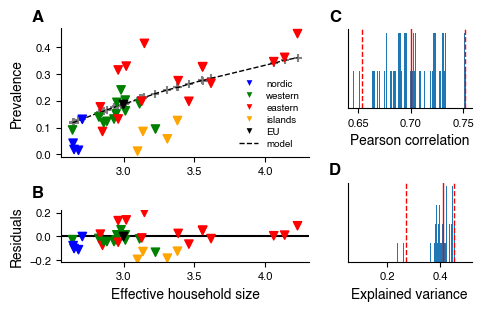

In [8]:
# plotting

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.titlesize"]= 8
mpl.rcParams["xtick.labelsize"] = 8
mpl.rcParams["ytick.labelsize"] = 8
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 7
mpl.rcParams["legend.title_fontsize"] = 7
mpl.rcParams["font.family"] = "Helvetica"
cm = 1/2.54

fig = plt.figure(figsize=(12*cm, 3), constrained_layout=True)
subfigs = fig.subfigures(1, 2, width_ratios=[2,1], wspace=0.05)
grid_left = subfigs[0].add_gridspec(ncols=1, nrows=2, height_ratios=[5,2], hspace=0.0)
grid_right = subfigs[1].add_gridspec(ncols=1, nrows=2, hspace=0.1)
ax1 = subfigs[0].add_subplot(grid_left[0])
ax2 = subfigs[0].add_subplot(grid_left[1], sharex=ax1)
ax3 = subfigs[1].add_subplot(grid_right[0])
ax4 = subfigs[1].add_subplot(grid_right[1])

ax1.scatter(df['mratio'], df['prev_real'], color=df['color'], marker='v')
ax1.scatter(eu_mratio, eu_prev, color='black', marker='v')
ax1.scatter(df['mratio'], df['prev_theo'], color='gray', marker='+', zorder=0)
#ax1.plot(df['mratio'], df['prev_theo_b'], color='red', lw=1, ls='--', zorder=0)
#ax1.plot(df['mratio'], df['prev_theo_w'], color='blue', lw=1, ls='--', zorder=0)
ax1.plot(df['mratio'], df['prev_theo'], color='black', lw=1, ls='--', zorder=0)
#ax1.set_xlabel(r'Effective household size')
ax1.set_ylabel(r'Prevalence')

ax2.scatter(df['mratio'], df['prev_real']-df['prev_theo'], color=df['color'], marker='v')
ax2.scatter(eu_mratio, 0, color='black', marker='v')
ax2.axhline(0, color='black', zorder=0)
ax2.set_xlabel(r'Effective household size')
ax2.set_ylabel(r'Residuals')

ax3.hist(pcc, bins=100, density=True)
ax3.axvline(np.percentile(pcc,2.5), color='red', lw=1, ls='--')
ax3.axvline(np.percentile(pcc,97.5), color='red', lw=1, ls='--')
ax3.axvline(np.percentile(pcc,50), color='red', lw=1)
ax3.set_xlabel(r'Pearson correlation')
#ax3.set_ylabel(r'Frequency')
ax3.set_yticks([])

ax4.hist(r2[r2>0], bins=100, density=True)
ax4.set_xlim(0.05, 0.52)
ax4.axvline(np.percentile(r2,2.5), color='red', lw=1, ls='--')
ax4.axvline(np.percentile(r2,97.5), color='red', lw=1, ls='--')
ax4.axvline(np.percentile(r2,50), color='red', lw=1)
ax4.set_xlabel('Explained variance')
ax4.set_yticks([])

ax1.text(-.12,1.05, 'A', size=12, weight='bold', color='black', transform=ax1.transAxes)
ax2.text(-.12,1.25, 'B', size=12, weight='bold', color='black', transform=ax2.transAxes)
ax3.text(-.15,1.1, 'C', size=12, weight='bold', color='black', transform=ax3.transAxes)
ax4.text(-.15,1.1, 'D', size=12, weight='bold', color='black', transform=ax4.transAxes)


legend_elements = [mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(nordic[0]), label='nordic'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(northwest[0]), label='western'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(udssr[0]), label='eastern'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(island[0]), label='islands'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor='black', label='EU'),
                   mpl.lines.Line2D([0], [0], color='black', lw=1, ls='--', label='model')]
ax1.legend(handles=legend_elements, frameon=False, labelspacing=0.3)

subfigs[0].align_ylabels()